# Probability & Statistics – Basics

Author: Joe  
Project: AI Foundations

This notebook is a working space for building intuition in **probability and statistics**.
We'll mix short theory notes, visualisations, and small simulations in Python.

Feel free to treat this as a living document: add examples, rewrite explanations in your own words,
and annotate with insights from your college course.

## Contents
1. [Sets, Events & Sample Spaces](#1-sets-events--sample-spaces)
2. [Basic Probability Rules](#2-basic-probability-rules)
3. [Conditional Probability & Bayes' Theorem](#3-conditional-probability--bayes-theorem)
4. [Discrete Random Variables](#4-discrete-random-variables)
    - Bernoulli
    - Binomial
    - Poisson
5. [Continuous Random Variables](#5-continuous-random-variables)
    - Uniform
    - Normal
6. [Expectation & Variance](#6-expectation--variance)
7. [Law of Large Numbers & Central Limit Theorem (preview)](#7-law-of-large-numbers--central-limit-theorem-preview)


In [1]:
# Standard imports
import math
import random

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

np.set_printoptions(precision=4, suppress=True)

---
## 1. Sets, Events & Sample Spaces

- **Sample space** $\Omega$: all possible outcomes of an experiment.
- **Event**: a subset of the sample space.

Example: Tossing a fair coin once
- $\Omega = \{H, T\}$
- Example event: $A = \{H\}$ = "we get heads".

Example: Rolling a fair six-sided die
- $\Omega = \{1,2,3,4,5,6\}$
- Event $B = \{2,4,6\}$ = "we get an even number".

In [2]:
# Simulate some simple sample spaces
coin_space = ['H', 'T']
die_space = [1, 2, 3, 4, 5, 6]

def simulate_coin_toss(n=10):
    return [random.choice(coin_space) for _ in range(n)]

def simulate_die_roll(n=10):
    return [random.choice(die_space) for _ in range(n)]

simulate_coin_toss(10), simulate_die_roll(10)

(['T', 'T', 'H', 'H', 'H', 'H', 'T', 'H', 'T', 'H'],
 [3, 3, 5, 1, 6, 1, 4, 6, 5, 1])

---
## 2. Basic Probability Rules

For a finite sample space with equally likely outcomes:
\begin{equation}
P(A) = \frac{|A|}{|\Omega|}
\end{equation}

Key rules:
- $0 \le P(A) \le 1$
- $P(\Omega) = 1$
- $P(\emptyset) = 0$
- Complement rule: $P(A^c) = 1 - P(A)$
- Addition rule (for any events):
  $$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

In [3]:
# Example: probability of an even number on a fair die
omega = np.array([1, 2, 3, 4, 5, 6])
A = np.array([2, 4, 6])  # event: even

P_A = len(A) / len(omega)
P_A

0.5

In [4]:
# Check probabilities empirically by simulation
def estimate_prob_even_on_die(n_trials=10000):
    rolls = np.random.randint(1, 7, size=n_trials)
    return np.mean(rolls % 2 == 0)

estimate_prob_even_on_die()

np.float64(0.4996)

---
## 3. Conditional Probability & Bayes' Theorem

**Conditional probability**:
\begin{equation}
P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0.
\end{equation}

**Bayes' theorem** (two events):
\begin{equation}
P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}.
\end{equation}

Concrete example: a simple medical test scenario.
- Disease prevalence: $P(D) = 0.01$
- Test is 99\% sensitive: $P(+ \mid D) = 0.99$
- Test is 95\% specific: $P(- \mid D^c) = 0.95$.

In [5]:
# Bayes' theorem: simple medical test example
P_D = 0.01         # disease prevalence
P_pos_given_D = 0.99
P_neg_given_notD = 0.95
P_pos_given_notD = 1 - P_neg_given_notD

# Total probability of a positive test
P_pos = P_pos_given_D * P_D + P_pos_given_notD * (1 - P_D)

# Bayes: P(D | +)
P_D_given_pos = P_pos_given_D * P_D / P_pos
P_D, P_pos, P_D_given_pos

(0.01, 0.05940000000000004, 0.16666666666666655)

---
## 4. Discrete Random Variables

A **random variable** is a function from the sample space to the real numbers.

Here we focus on some classic discrete distributions:

### 4.1 Bernoulli$(p)$
- Models a single trial with outcome 1 ("success") with probability $p$ and 0 ("failure") with probability $1-p$.
- $P(X=1) = p$, $P(X=0) = 1-p$.
- $\mathbb{E}[X] = p$, $\text{Var}(X) = p(1-p)$.

### 4.2 Binomial$(n, p)$
- Number of successes in $n$ independent Bernoulli$(p)$ trials.
- $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$, for $k=0,1,\dots,n$.
- $\mathbb{E}[X] = np$, $\text{Var}(X) = np(1-p)$.

### 4.3 Poisson$(\lambda)$
- Models counts of events in a fixed interval when events occur independently at rate $\lambda$.
- $P(X = k) = e^{-\lambda} \frac{\lambda^k}{k!}$, for $k = 0,1,2,\dots$.
- $\mathbb{E}[X] = \lambda$, $\text{Var}(X) = \lambda$.

In [6]:
# Simulate Bernoulli and Binomial and compare to theory
def simulate_bernoulli(p=0.3, n=10000):
    return np.random.rand(n) < p

def simulate_binomial(n_trials=10, p=0.3, n_samples=10000):
    return np.random.binomial(n_trials, p, size=n_samples)

p = 0.3
bern_samples = simulate_bernoulli(p=p)

print('Bernoulli empirical mean:', bern_samples.mean())
print('Bernoulli theoretical mean:', p)

binom_samples = simulate_binomial(10, p, 10000)
print('Binomial empirical mean:', binom_samples.mean())
print('Binomial theoretical mean:', 10 * p)

Bernoulli empirical mean: 0.3104
Bernoulli theoretical mean: 0.3
Binomial empirical mean: 3.0112
Binomial theoretical mean: 3.0


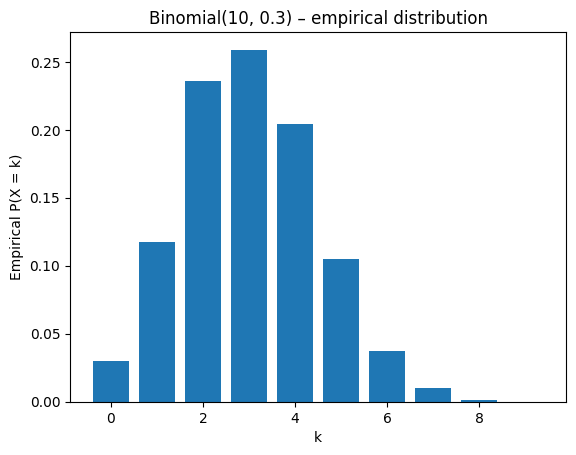

In [7]:
# Visualise Binomial(10, 0.3)
from collections import Counter

counts = Counter(binom_samples)
ks = sorted(counts.keys())
freqs = np.array([counts[k] for k in ks]) / len(binom_samples)

plt.bar(ks, freqs)
plt.xlabel('k')
plt.ylabel('Empirical P(X = k)')
plt.title('Binomial(10, 0.3) – empirical distribution')
plt.show()

---
## 5. Continuous Random Variables

Continuous distributions are described by a **probability density function** (pdf) $f(x)$.

### 5.1 Uniform$(a,b)$
- $X \sim \text{Uniform}(a,b)$ has pdf
  $$f(x) = \frac{1}{b-a} \quad \text{for } a \le x \le b.$$
- All points in $[a,b]$ are equally likely.

### 5.2 Normal$(\mu, \sigma^2)$
- Bell-shaped distribution
- pdf
  $$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right).$$
- Very important in statistics (Central Limit Theorem).

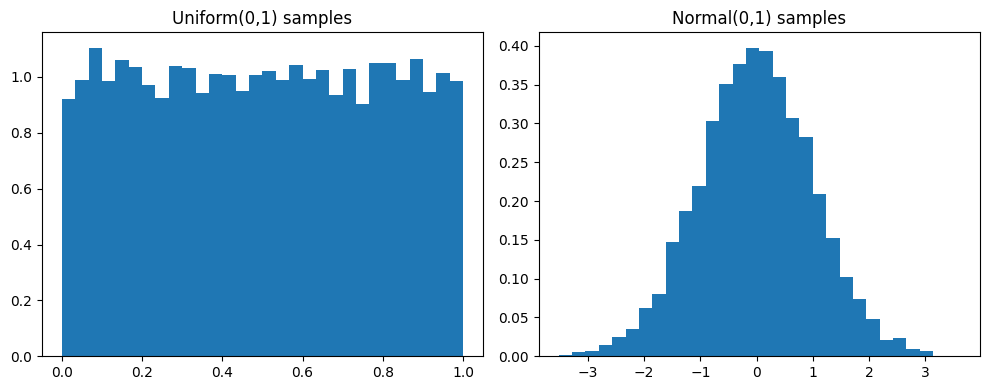

In [8]:
# Visualise samples from Uniform(0,1) and Normal(0,1)
uniform_samples = np.random.rand(10000)
normal_samples = np.random.randn(10000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(uniform_samples, bins=30, density=True)
axes[0].set_title('Uniform(0,1) samples')

axes[1].hist(normal_samples, bins=30, density=True)
axes[1].set_title('Normal(0,1) samples')

plt.tight_layout()
plt.show()

---
## 6. Expectation & Variance

- **Expectation** $\mathbb{E}[X]$ is the long-run average value of $X$.
- **Variance** $\text{Var}(X)$ measures spread around the mean.

For a discrete random variable $X$ with pmf $p(x)$:
\begin{align}
\mathbb{E}[X] &= \sum_x x p(x), \\
\text{Var}(X) &= \mathbb{E}[(X - \mathbb{E}[X])^2].
\end{align}

In practice, we often estimate these from data using **sample mean** and **sample variance**.

In [9]:
# Example: empirical mean and variance for Normal(0,1)
samples = np.random.randn(100000)

sample_mean = samples.mean()
sample_var = samples.var(ddof=1)  # unbiased estimator

sample_mean, sample_var

(np.float64(-0.0025186259462102274), np.float64(0.9998171809029328))

---
## 7. Law of Large Numbers & Central Limit Theorem (preview)

**Law of Large Numbers (LLN)**:
- The sample mean of i.i.d. random variables converges to the true mean as the sample size grows.

**Central Limit Theorem (CLT)**:
- Under mild conditions, the distribution of the (properly scaled) sample mean becomes approximately Normal as the sample size increases.

Here we visualise the LLN for a Bernoulli random variable.

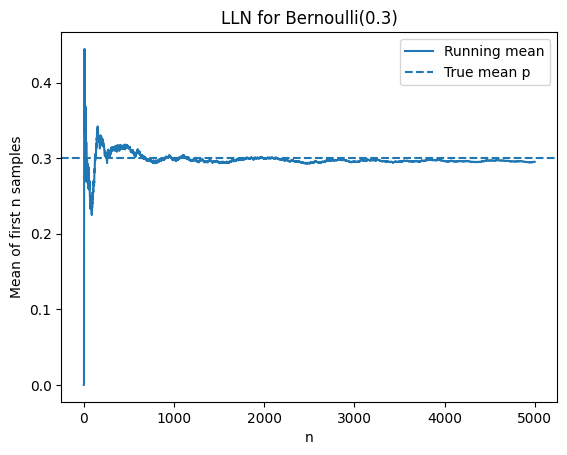

In [10]:
# LLN demo for Bernoulli(0.3)
p = 0.3
n = 5000
samples = (np.random.rand(n) < p).astype(float)

running_mean = np.cumsum(samples) / (np.arange(n) + 1)

plt.plot(running_mean, label='Running mean')
plt.axhline(p, linestyle='--', label='True mean p')
plt.xlabel('n')
plt.ylabel('Mean of first n samples')
plt.title('LLN for Bernoulli(0.3)')
plt.legend()
plt.show()

---
### Next steps / TODOs
- Add worked examples from your course sheets (Bernoulli, Binomial, Poisson questions).
- Add a section on **confidence intervals** for a proportion and a mean.
- Add a section on **hypothesis testing** (Z-tests, t-tests, etc.).
- Translate R-based coursework examples into Python here (or mirror them alongside R code).

Use this as your base notebook and fork new ones for deeper dives, e.g.:
- `01_probability_basics.ipynb`
- `02_discrete_distributions.ipynb`
- `03_continuous_distributions.ipynb`
- `04_inference_confidence_intervals.ipynb`